# 3 · Decoding

**What you will do:** turn "the structure is visible" into a number a downstream reader could actually use — with every control that makes the number mean something.

**What you should take away:** an accuracy without a chance level, a null and a held-out split is not a result. Also: this population is *redundant*, and that fact drives notebook 4.

Runtime: three to four minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, decoding, geometry, plotting

plotting.apply_style()
rng = np.random.default_rng(2026)

shd = data.load("train")
subset = rng.choice(np.flatnonzero(shd.english_mask()), size=1500, replace=False)

X, y, t = data.build_design_matrix(shd, bin_ms=25.0, t_max_ms=800.0, smooth_ms=10.0, trials=subset)
Xf = data.flatten(X)
speaker = shd.speaker[subset]

print("X ", X.shape)
print("chance level", round(decoding.chance_level(y), 3))

X  (1500, 700, 32)
chance level 0.11


## One number and its three controls

In [2]:
res = decoding.decode(Xf, y, estimator=decoding.make_readout("ridge"))
null = decoding.shuffle_control(Xf, y, n_repeats=3)

print(f"accuracy          {res['mean']:.3f}  ± {res['std']:.3f}")
print(f"chance            {res['chance']:.3f}")
print(f"shuffled labels   {null.mean():.3f}  ± {null.std():.3f}")

accuracy          0.885  ± 0.020
chance            0.110
shuffled labels   0.100  ± 0.013


The **shuffled-label null** is stronger than chance: it absorbs any leakage the pipeline happens to have. If your accuracy is not clearly above that distribution you have not shown anything.

## Random split versus speaker held out

Random cross-validation lets the classifier see other utterances by the same speaker. Holding whole speakers out asks whether you learned the digit or the voice.

generalisation gap  0.259


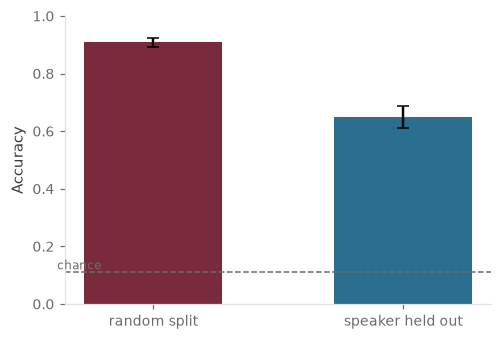

In [3]:
res_random = decoding.decode(Xf, y)
res_speaker = decoding.decode(Xf, y, groups=speaker)

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar([0, 1], [res_random["mean"], res_speaker["mean"]],
       yerr=[res_random["std"], res_speaker["std"]],
       color=[plotting.ACCENT, plotting.PALETTE[1]], width=0.55, linewidth=0, capsize=4)
ax.axhline(res["chance"], ls="--", lw=1, color=plotting.INK_MUTED)
ax.text(-0.4, res["chance"], " chance", va="bottom", fontsize=8, color=plotting.INK_MUTED)
ax.set_xticks([0, 1])
ax.set_xticklabels(["random split", "speaker held out"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)

print(f"generalisation gap  {res_random['mean'] - res_speaker['mean']:.3f}")

**Report both.** The gap between them is a result in its own right: it is how much of the random-split accuracy came from recognising voices rather than digits.

## Reproducing the published baseline

Cramer et al. (2020), Figure 3: classifiers with no access to spike timing plateau near **60 %**; temporally aware ones reach **~85 %**.

Summing over time destroys timing. Keeping the bins preserves it. You will not match their exact numbers — different classifier, different subset — but the *gap* should reproduce. If it does not, something in your pipeline is wrong.

counts only  0.809   (published ~0.60)
with timing  0.909   (published ~0.85)


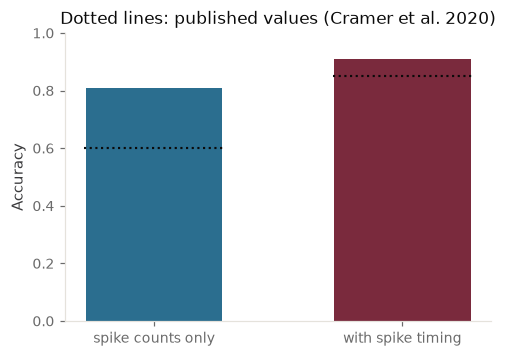

In [4]:
res_counts = decoding.decode(X.sum(axis=2), y)      # timing destroyed
res_timing = decoding.decode(Xf, y)                 # timing kept

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar([0, 1], [res_counts["mean"], res_timing["mean"]],
       color=[plotting.PALETTE[1], plotting.ACCENT], width=0.55, linewidth=0)
for x_, r_, ref in [(0, res_counts, 0.60), (1, res_timing, 0.85)]:
    ax.hlines(ref, x_ - 0.28, x_ + 0.28, color=plotting.INK, lw=1.4, ls=":")
ax.set_xticks([0, 1])
ax.set_xticklabels(["spike counts only", "with spike timing"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Dotted lines: published values (Cramer et al. 2020)")

print(f"counts only  {res_counts['mean']:.3f}   (published ~0.60)")
print(f"with timing  {res_timing['mean']:.3f}   (published ~0.85)")

## Learning curves

Are you limited by data, or by the representation?

 channels  accuracy
       10     0.541
       25     0.472
       50     0.433
      100     0.694
      200     0.819
      400     0.856
      700     0.885


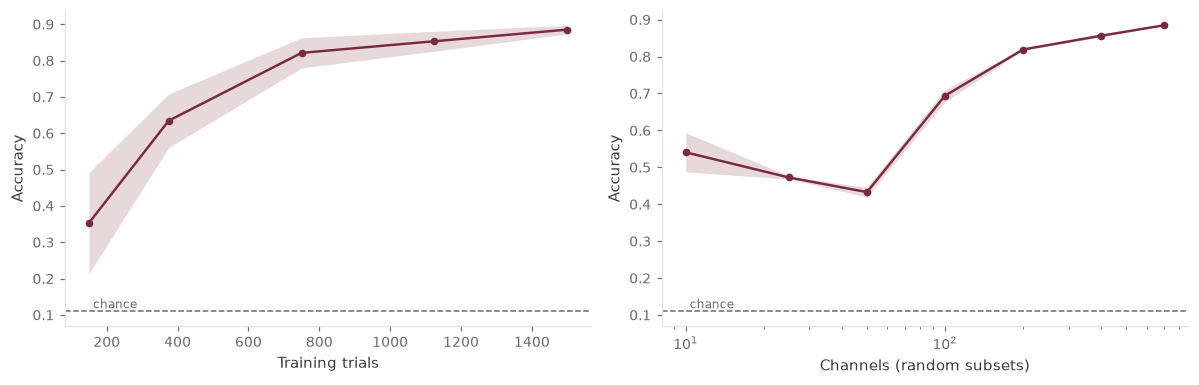

In [5]:
n_trials, m_trials, s_trials = decoding.learning_curve_trials(Xf, y)
n_chan, m_chan, s_chan = decoding.learning_curve_channels(X, y, n_repeats=3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
plotting.learning_curve(n_trials, m_trials, s_trials, ax=axes[0],
                        chance=res["chance"], xlabel="Training trials")
plotting.learning_curve(n_chan, m_chan, s_chan, ax=axes[1],
                        chance=res["chance"], xlabel="Channels (random subsets)")
axes[1].set_xscale("log")
fig.tight_layout()
plotting.savefig(fig, "03_learning_curves", outdir="../plots")

print(pd.DataFrame({"channels": n_chan, "accuracy": np.round(m_chan, 3)}).to_string(index=False))

**The channel curve is the important one.** Accuracy is already near its ceiling with a small fraction of the 700 channels. That means the code is **massively redundant** — many different subsets carry the same information.

Hold on to this. It is why "which channels are important?" turns out to be such a hard question in notebook 4, and why the honest answer there is a number rather than a list.

## When does the digit become decodable?

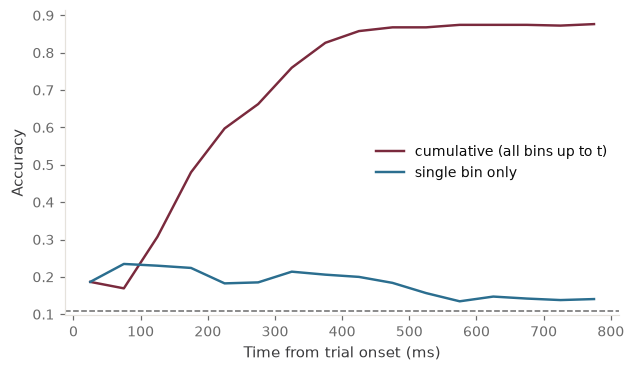

In [6]:
X50, y50, t50 = data.build_design_matrix(shd, bin_ms=50.0, t_max_ms=800.0,
                                         smooth_ms=10.0, trials=subset)
t_ms, acc_cum = decoding.accuracy_over_time(X50, y50, t50, cumulative=True)
_, acc_bin = decoding.accuracy_over_time(X50, y50, t50, cumulative=False)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(t_ms, acc_cum, label="cumulative (all bins up to t)", color=plotting.ACCENT)
ax.plot(t_ms, acc_bin, label="single bin only", color=plotting.PALETTE[1])
ax.axhline(decoding.chance_level(y50), ls="--", lw=1, color=plotting.INK_MUTED)
ax.set_xlabel("Time from trial onset (ms)")
ax.set_ylabel("Accuracy")
ax.legend()

The cumulative curve is what a downstream reader would have access to. The single-bin curve localises *where* in the trial the information is, but it ignores that a real reader can integrate over time.

## The actual question of this project

**Does any geometric property predict decodability?** This is assumed constantly in the population-coding literature and tested rarely.

In [7]:
# The sweep refits a readout for every condition. Keep it honest but cheap:
# a smaller trial subset, and bins coarse enough that the design matrix stays
# in the tens of thousands of features rather than the hundreds of thousands.
sweep_trials = rng.choice(subset, size=600, replace=False)

rows = []
for bin_ms in [25.0, 50.0, 100.0, 200.0]:
    for smooth_ms in [0.0, 20.0, 50.0]:
        Xc, yc, _ = data.build_design_matrix(shd, bin_ms=bin_ms, t_max_ms=800.0,
                                             smooth_ms=smooth_ms, trials=sweep_trials)
        Xcf = data.flatten(Xc)
        rows.append({"bin_ms": bin_ms, "smooth_ms": smooth_ms,
                     "accuracy": decoding.decode(Xcf, yc, estimator=decoding.make_readout("ridge"))["mean"],
                     **geometry.summarize(Xcf, yc)})

sweep = pd.DataFrame(rows)
sweep.round(3)

,bin_ms,smooth_ms,accuracy,participation_ratio,class_separation,between_class_distance,within_class_radius
0,25.0,0.0,0.815,22.121,0.182,61.176,100.200
1,25.0,20.0,0.837,11.358,0.261,56.753,77.643
2,25.0,50.0,0.837,7.244,0.298,47.154,60.551
3,50.0,0.0,0.823,13.742,0.238,83.290,119.520
4,50.0,20.0,0.828,12.528,0.249,81.215,114.001
5,50.0,50.0,0.838,7.199,0.297,66.130,85.036
6,100.0,0.0,0.825,9.550,0.280,107.751,141.700
7,100.0,20.0,0.825,9.550,0.280,107.750,141.700
8,100.0,50.0,0.822,7.767,0.287,94.198,122.928
9,200.0,0.0,0.725,5.921,0.321,131.397,164.780


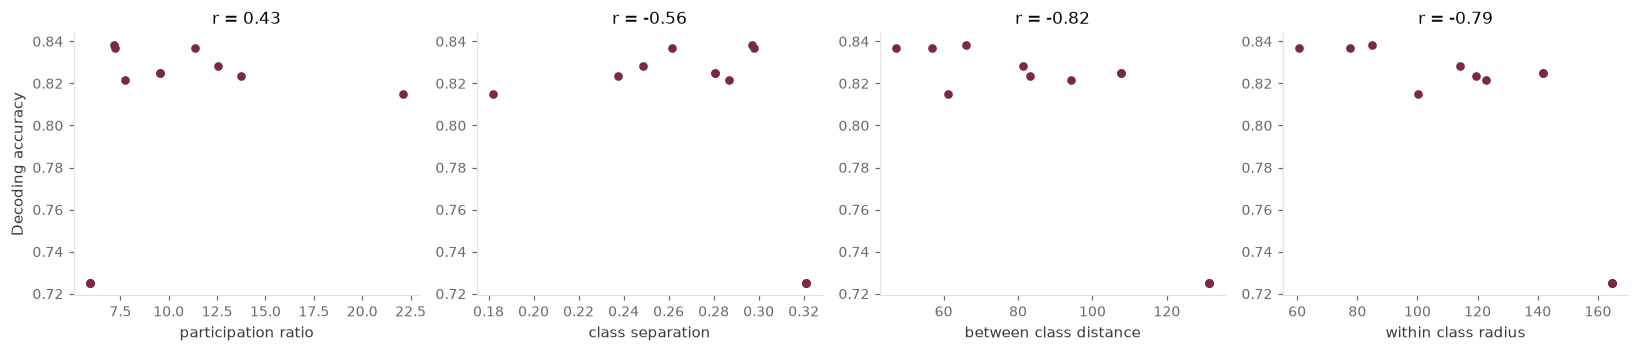

In [8]:
props = ["participation_ratio", "class_separation", "between_class_distance", "within_class_radius"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, p in zip(axes, props):
    ax.scatter(sweep[p], sweep["accuracy"], color=plotting.ACCENT, s=32, linewidths=0)
    r = np.corrcoef(sweep[p], sweep["accuracy"])[0, 1]
    ax.set_xlabel(p.replace("_", " "))
    ax.set_title(f"r = {r:.2f}")
axes[0].set_ylabel("Decoding accuracy")
fig.tight_layout()
plotting.savefig(fig, "03_geometry_vs_decoding", outdir="../plots")

**Interpret this carefully — it is the easiest place in the project to overclaim.**

A correlation *across preprocessing conditions* is not a causal claim about geometry. Both quantities are functions of the same two knobs, so they can co-vary without either predicting the other in any useful sense.

What would a better test look like? That question is worth a paragraph in your report, and answering it well would be a genuine contribution.

---

## Exercises

1. **Ridge versus logistic.** Do they agree? If not, which do you trust and why?
2. **Confusion structure.** Plot the confusion matrix. Which digits get confused, and does the pattern make acoustic sense?
3. **A nonlinear ceiling.** Fit an RBF-kernel SVM or a small MLP. The gap to the linear readout bounds how much structure is *not* linearly accessible.
4. **A stricter timing control.** Compare against the temporal-shuffle surrogate from notebook 1 rather than against summed counts. Does the "timing matters" conclusion survive?

Next: **[4 · Interpretability](04_interpretability.ipynb)** — what carries the signal.